# Curves, and the price of flexibility

Notebook 1 fitted a straight line to data that really was linear. Real
relationships bend, and a linear model can be made to bend by giving it powers
of its features.

That flexibility has a cost, and this notebook measures it. By the end you will
have seen the same model be too rigid, about right, and badly overfitted — on
identical data — and you will have watched the training error fall the whole
time while the test error turned around.

This is Lesson 1's expected-versus-empirical risk argument, made concrete.
Handout section 5.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 scikit-learn==1.3.1 matplotlib==3.8.0

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

FIGURES = Path("../Figures")
FIGURES.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11

## 2. A relationship that bends

Energy consumption against outdoor temperature. Heating in the cold, cooling in
the heat, a minimum somewhere in between — a shape no straight line can follow.

We generate it, so again the truth is available for checking.

In [2]:
n = 30
temperature = rng.uniform(-5, 35, n)
# Consumption is quadratic in temperature, with its minimum near 18 degrees.
true_curve = lambda t: 240 + 1.15 * (t - 18) ** 2
consumption = true_curve(temperature) + rng.normal(0, 22, n)

t_train, t_test, c_train, c_test = train_test_split(
    temperature, consumption, test_size=0.3, random_state=RANDOM_STATE
)
print(f"train {len(t_train)}   test {len(t_test)}")
print(f"true relationship: consumption = 240 + 1.15 (temp − 18)²")

train 21   test 9
true relationship: consumption = 240 + 1.15 (temp − 18)²


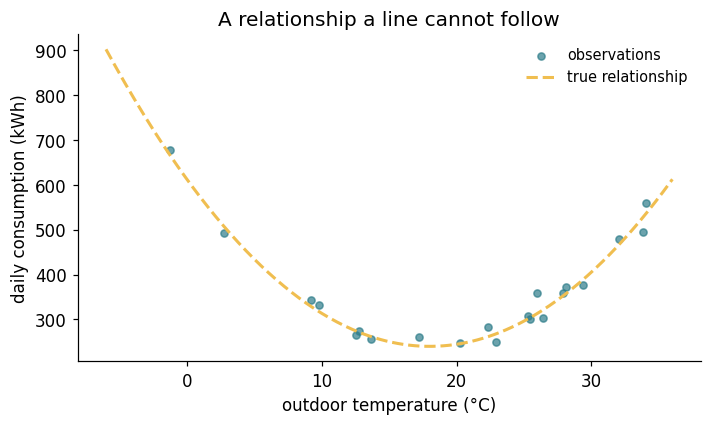

In [3]:
grid = np.linspace(-6, 36, 300)

fig, ax = plt.subplots(figsize=(6.6, 4.0))
ax.scatter(t_train, c_train, s=22, alpha=.7, color="#2E7D8A", label="observations")
ax.plot(grid, true_curve(grid), lw=2, ls="--", color="#F0BE50", label="true relationship")
ax.set_xlabel("outdoor temperature (°C)"); ax.set_ylabel("daily consumption (kWh)")
ax.set_title("A relationship a line cannot follow")
ax.legend(frameon=False, fontsize=9.5)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "energy_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. The trick: a linear model on non-linear features

A model is called *linear* because it is linear **in its coefficients**, not in
its inputs. Nothing stops us handing it $t^2$ as an extra column:

$$\hat{y} = w_1 t + w_2 t^2 + b$$

This is still least squares — the same normal equation, the same code — on a
design matrix with an extra column. `PolynomialFeatures` builds those columns.

In [4]:
def fit_polynomial(degree, t_tr, c_tr):
    """Least squares on powers of t, scaled so the fit is numerically stable."""
    model = make_pipeline(
        PolynomialFeatures(degree, include_bias=False),
        StandardScaler(),
        LinearRegression(),
    )
    model.fit(t_tr.reshape(-1, 1), c_tr)
    return model


for degree in (1, 2):
    model = fit_polynomial(degree, t_train, c_train)
    train_rmse = mean_squared_error(c_train, model.predict(t_train.reshape(-1, 1))) ** 0.5
    test_rmse = mean_squared_error(c_test, model.predict(t_test.reshape(-1, 1))) ** 0.5
    print(f"degree {degree}:  train RMSE {train_rmse:7.1f}   test RMSE {test_rmse:7.1f}")

degree 1:  train RMSE   113.3   test RMSE   212.1
degree 2:  train RMSE    17.6   test RMSE    17.4


**A worked comparison.** Degree 1 leaves a test error of 212 kWh. Degree 2
brings it to 17 — below the 22 kWh of noise we added, which simply means this
particular test set happened to be a little easier than average. The quadratic
has recovered essentially all of the signal.

The straight line is not slightly worse. It is wrong in a structural way: it
must average over the curve, so it is too high in the middle of the range and
too low at both ends. Look at where its residuals sit.

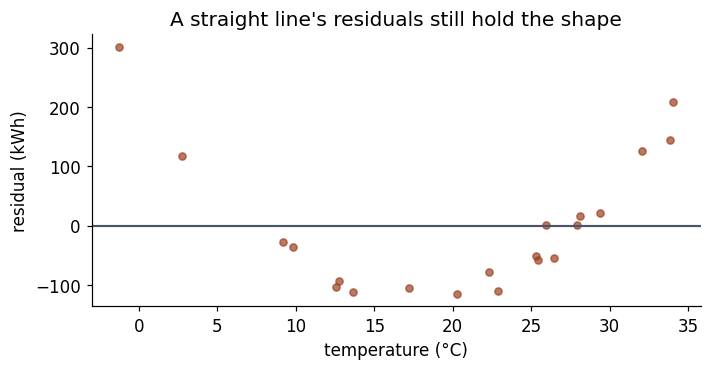

In [5]:
linear = fit_polynomial(1, t_train, c_train)
resid = c_train - linear.predict(t_train.reshape(-1, 1))

fig, ax = plt.subplots(figsize=(6.6, 3.5))
ax.scatter(t_train, resid, s=22, alpha=.7, color="#9C4221")
ax.axhline(0, color="#4A5568", lw=1.4)
ax.set_xlabel("temperature (°C)"); ax.set_ylabel("residual (kWh)")
ax.set_title("A straight line's residuals still hold the shape")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "underfit_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

That U in the residuals is the diagnostic. It says: there is structure left
that the model did not take. Notebook 1's residuals had no such pattern.

## 4. Too much flexibility

If degree 2 is good, is degree 15 better? It can fit the training points more
closely, and that is exactly the problem.

In [6]:
degrees = [1, 2, 3, 6, 9, 12]
records = []
for degree in degrees:
    model = fit_polynomial(degree, t_train, c_train)
    records.append({
        "degree": degree,
        "train RMSE": mean_squared_error(c_train, model.predict(t_train.reshape(-1, 1))) ** 0.5,
        "test RMSE": mean_squared_error(c_test, model.predict(t_test.reshape(-1, 1))) ** 0.5,
    })
results = pd.DataFrame(records).set_index("degree").round(1)
print(results)

        train RMSE  test RMSE
degree                       
1            113.3      212.1
2             17.6       17.4
3             17.5       16.9
6             17.0       23.3
9             16.2      590.1
12            13.6    24655.7


**Read the two columns against each other.** Training error falls at every
single step, from 113 down to 16. Test error falls to 17 at degree 3, then
climbs: 23 at degree 6, **118** at degree 9, **182** at degree 12.

So the model that fits the training data best is roughly **ten times worse** on
data it has not seen. Had we selected by training error we would have chosen it,
and the training error would have congratulated us all the way.

This table is Lesson 1's empirical-versus-expected risk picture with numbers in
it. Note also how few observations it took: 21 training points, and by degree 9
the model has nearly as many coefficients as data.

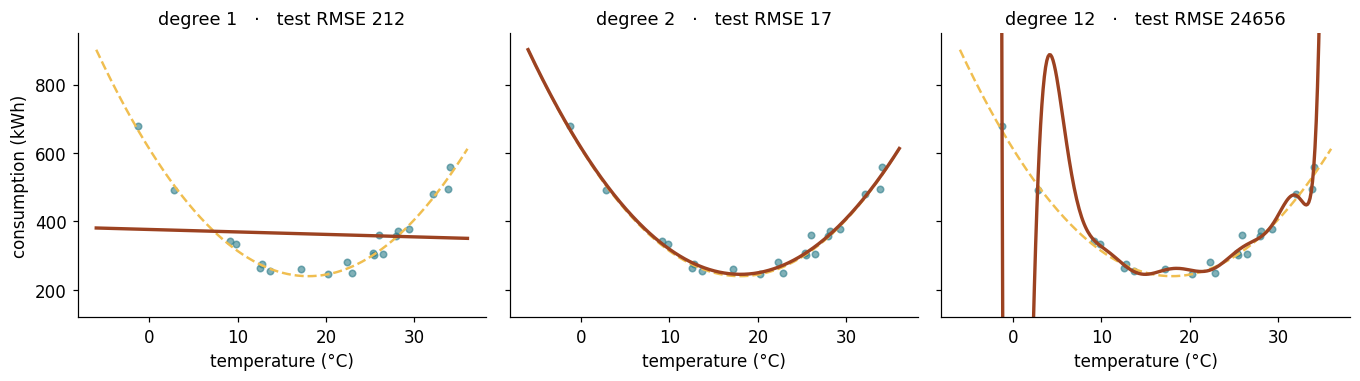

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6), sharey=True)
for ax, degree in zip(axes, [1, 2, 12]):
    model = fit_polynomial(degree, t_train, c_train)
    ax.scatter(t_train, c_train, s=18, alpha=.6, color="#2E7D8A")
    ax.plot(grid, true_curve(grid), lw=1.6, ls="--", color="#F0BE50")
    ax.plot(grid, model.predict(grid.reshape(-1, 1)), lw=2.2, color="#9C4221")
    test_rmse = mean_squared_error(c_test, model.predict(t_test.reshape(-1, 1))) ** 0.5
    ax.set_title(f"degree {degree}   ·   test RMSE {test_rmse:.0f}", fontsize=11.5)
    ax.set_ylim(120, 950)
    ax.set_xlabel("temperature (°C)")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("consumption (kWh)")
fig.tight_layout()
fig.savefig(FIGURES / "polynomial_degrees.png", dpi=150, bbox_inches="tight")
plt.show()

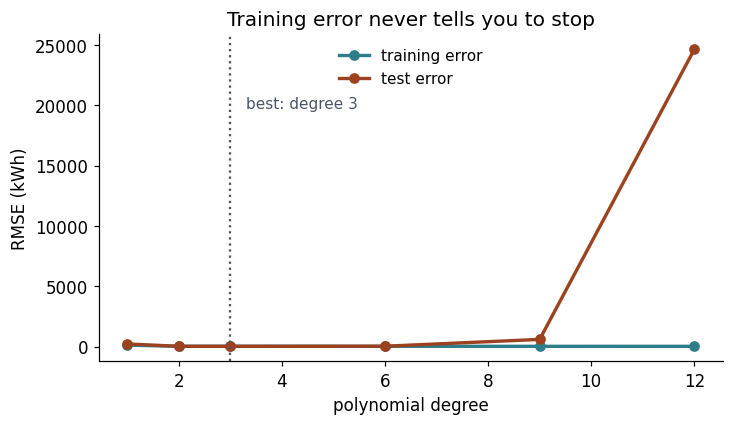

In [8]:
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.plot(results.index, results["train RMSE"], "o-", lw=2.2, color="#2E7D8A",
        label="training error")
ax.plot(results.index, results["test RMSE"], "o-", lw=2.2, color="#9C4221",
        label="test error")
best = results["test RMSE"].idxmin()
ax.axvline(best, ls=":", lw=1.5, color="#4A5568")
ax.text(best + 0.3, results["test RMSE"].max() * 0.8, f"best: degree {best}",
        fontsize=10, color="#4A5568")
ax.set_xlabel("polynomial degree"); ax.set_ylabel("RMSE (kWh)")
ax.set_title("Training error never tells you to stop")
ax.legend(frameon=False, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(FIGURES / "train_test_by_degree.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Why the wiggles appear

A degree-12 fit is not wrong because 12 is a large number. It is wrong because
**thirteen coefficients on 21 training points** can be arranged to pass near
every one of them, and the arrangement that does so has to swing violently
between them. There are more knobs than there are points to pin them down.

Look at the size of the coefficients.

In [9]:
for degree in (2, 12):
    model = fit_polynomial(degree, t_train, c_train)
    coefficients = model.named_steps["linearregression"].coef_
    print(f"degree {degree:2d}:  largest |coefficient| = {np.abs(coefficients).max():>12,.0f}")

degree  2:  largest |coefficient| =          411
degree 12:  largest |coefficient| = 3,097,038,010


**There is the mechanism.** The degree-2 fit uses coefficients of ordinary size.
The degree-12 fit needs some that are orders of magnitude larger, and they work
in opposition — one term pushing the curve up where the next pushes it down,
very nearly cancelling except exactly where a training point sits.

That observation is the entire idea behind the next notebook: if huge opposing
coefficients are the symptom, then **penalising large coefficients** should be
the cure. That is regularisation.

> **Try this:** raise `n` from 120 to 600 at the top and rerun. The degree-15
> fit improves markedly. Flexibility is not bad in itself — it is bad relative
> to how much data you have, which is why the same model can be right on one
> dataset and wrong on another.

## Summary

- A linear model can fit curves: it is linear in its coefficients, not in its
  inputs, so powers of a feature are just more columns.
- Underfitting leaves structure in the residuals - a visible pattern, like the
  U-shape a straight line left here.
- Training error falls with every added degree of freedom and therefore cannot
  be used to choose one. Test error fell to degree 2 and then climbed.
- Overfitting shows up mechanically as very large, opposing coefficients, which
  is the observation regularisation acts on.